In [2]:
!pip install lightgbm

  Obtaining dependency information for lightgbm from https://files.pythonhosted.org/packages/d5/0b/c5c17d862b12ce292f24cd85d40f2f8f8981668fbdbd43fdc2625eccbc79/lightgbm-4.7.0-py3-none-win_amd64.whl.metadata
  Obtaining dependency information for narwhals>=1.15 from https://files.pythonhosted.org/packages/7e/85/a5bfaebfd305ac18b57b0854d74e37e586809061a91fda62f0bd50c8518e/narwhals-2.24.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   - -------------------------------------- 0.0/1.4 MB 393.8 kB/s eta 0:00:04
   --- ------------------------------------ 0.1/1.4 MB 819.2 kB/s eta 0:00:02
   ----- ---------------------------------- 0.2/1.4 MB 952.6 kB/s eta 0:00:02
   -------- ------------------------------- 0.3/1.4 MB 1.3 MB/s eta 0:00:01
   -------------- ------------------------- 0.5/1.4 MB 1.8 MB/s eta 0:00:01
   --------------------- ------------------ 0.7/1.4 MB 2.3 MB

In [3]:
# 导入库
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# 显示全部列
pd.set_option('display.max_columns', None)

In [5]:
train = pd.read_csv("./data/1/round1_ijcai_18_train_20180301.txt", sep=' ')
test = pd.read_csv("./data/1/round1_ijcai_18_test_a_20180301.txt", sep=' ')

print("训练集shape", train.shape)
print("测试集shape", test.shape)
print(train.columns.tolist())
train.head()

训练集shape (478138, 27)
测试集shape (18371, 26)
['instance_id', 'item_id', 'item_category_list', 'item_property_list', 'item_brand_id', 'item_city_id', 'item_price_level', 'item_sales_level', 'item_collected_level', 'item_pv_level', 'user_id', 'user_gender_id', 'user_age_level', 'user_occupation_id', 'user_star_level', 'context_id', 'context_timestamp', 'context_page_id', 'predict_category_property', 'shop_id', 'shop_review_num_level', 'shop_review_positive_rate', 'shop_star_level', 'shop_score_service', 'shop_score_delivery', 'shop_score_description', 'is_trade']


,instance_id,item_id,item_category_list,item_property_list,item_brand_id,item_city_id,item_price_level,item_sales_level,item_collected_level,item_pv_level,user_id,user_gender_id,user_age_level,user_occupation_id,user_star_level,context_id,context_timestamp,context_page_id,predict_category_property,shop_id,shop_review_num_level,shop_review_positive_rate,shop_star_level,shop_score_service,shop_score_delivery,shop_score_description,is_trade
0,108641074714126964,3412720377098676069,7908382889764677758;5799347067982556520,2072967855524022579;5131280576272319091;263639...,1975590437749032870,3948283326616421003,3,3,4,14,4505772604969228686,1,1003,2005,3003,282924576738839389,1537236544,4006,5799347067982556520:-1;509660095530134768:-1;5...,6765930309048922341,4,1.0,5002,1.0,1.0,1.0,0
1,5754713551599725161,3412720377098676069,7908382889764677758;5799347067982556520,2072967855524022579;5131280576272319091;263639...,1975590437749032870,3948283326616421003,3,3,4,14,2692638157208937547,0,1002,2005,3006,4007979028023783431,1537243232,4001,5799347067982556520:9172976955054793469;790838...,6765930309048922341,4,1.0,5002,1.0,1.0,1.0,0
2,842679481291040981,3412720377098676069,7908382889764677758;5799347067982556520,2072967855524022579;5131280576272319091;263639...,1975590437749032870,3948283326616421003,3,3,4,14,5247924392014515924,0,1003,2005,3004,4884875192608989870,1537211052,4001,5799347067982556520:5131280576272319091;725801...,6765930309048922341,4,1.0,5002,1.0,1.0,1.0,0
3,937088850059189027,3412720377098676069,7908382889764677758;5799347067982556520,2072967855524022579;5131280576272319091;263639...,1975590437749032870,3948283326616421003,3,3,4,14,2681414445369714628,1,1004,2005,3006,840119421106178602,1537222670,4016,509660095530134768:-1;5799347067982556520:-1;7...,6765930309048922341,4,1.0,5002,1.0,1.0,1.0,0
4,7975697065017708072,3412720377098676069,7908382889764677758;5799347067982556520,2072967855524022579;5131280576272319091;263639...,1975590437749032870,3948283326616421003,3,3,4,14,2729475788342039013,0,1002,2005,3001,1736769971710354684,1537271320,4001,5799347067982556520:9172976955054793469;790838...,6765930309048922341,4,1.0,5002,1.0,1.0,1.0,0


In [6]:
print(train['is_trade'].value_counts(normalize=True))

0    0.981133
1    0.018867
Name: is_trade, dtype: float64


In [8]:
import datetime

def parse_time(ts):
    dt = datetime.datetime.fromtimestamp(ts)
    return dt.day, dt.hour

# 训练集
train['day'], train['hour'] = zip(*train['context_timestamp'].apply(parse_time))
# 测试集
test['day'], test['hour'] = zip(*test['context_timestamp'].apply(parse_time))

print(train[['context_timestamp','day','hour']].head())

   context_timestamp  day  hour
0         1537236544   18    10
1         1537243232   18    12
2         1537211052   18     3
3         1537222670   18     6
4         1537271320   18    19


In [10]:
# 标记样本来源
train['is_test'] = 0
test['is_test'] = 1
test['is_trade'] = -1  # 测试集标签占位

# 拼接全量数据
all_df = pd.concat([train, test], axis=0, ignore_index=True)
print("合并后全量数据shape", all_df.shape)

# 拆分item_category_list，取第一级主类目，使用np.int64支持超大id
all_df['item_category_1'] = all_df['item_category_list'].str.split(';').str[0].astype(np.int64)

# 查看结果
all_df[['item_category_list','item_category_1']].head()

合并后全量数据shape (496509, 30)


,item_category_list,item_category_1
0,7908382889764677758;5799347067982556520,7908382889764677758
1,7908382889764677758;5799347067982556520,7908382889764677758
2,7908382889764677758;5799347067982556520,7908382889764677758
3,7908382889764677758;5799347067982556520,7908382889764677758
4,7908382889764677758;5799347067982556520,7908382889764677758


In [11]:
# 查看各day样本数量
print(all_df['day'].value_counts().sort_index())

# 获取训练集最大的day，验证集就用这一天（时间分割，模拟未来预测）
max_day = all_df[all_df['is_test']==0]['day'].max()
print("训练数据最大day：", max_day)

# 构造mask
train_mask = (all_df['is_test']==0) & (all_df['day'] < max_day)
val_mask   = (all_df['is_test']==0) & (all_df['day'] == max_day)
test_mask  = (all_df['is_test']==1)

print(f"训练样本:{train_mask.sum()}, 验证样本:{val_mask.sum()}, 测试样本:{test_mask.sum()}")

18    78268
19    70931
20    68387
21    71199
22    68318
23    63614
24    57421
25    18371
Name: day, dtype: int64
训练数据最大day： 24
训练样本:420717, 验证样本:57421, 测试样本:18371


In [12]:
# 模型输入特征
feature_cols = [
    'item_id','item_category_1','item_brand_id','item_city_id',
    'item_price_level','item_sales_level','item_collected_level','item_pv_level',
    'user_id','user_gender_id','user_age_level','user_occupation_id','user_star_level',
    'context_page_id','day','hour',
    'shop_id','shop_review_num_level','shop_review_positive_rate',
    'shop_star_level','shop_score_service','shop_score_delivery','shop_score_description'
]

# 拆分X/y
X_train = all_df.loc[train_mask, feature_cols].copy()
y_train = all_df.loc[train_mask, 'is_trade'].copy()

X_val = all_df.loc[val_mask, feature_cols].copy()
y_val = all_df.loc[val_mask, 'is_trade'].copy()

X_test = all_df.loc[test_mask, feature_cols].copy()

# 填充店铺评分缺失
X_train['shop_review_positive_rate'] = X_train['shop_review_positive_rate'].fillna(0)
X_val['shop_review_positive_rate'] = X_val['shop_review_positive_rate'].fillna(0)
X_test['shop_review_positive_rate'] = X_test['shop_review_positive_rate'].fillna(0)

print(f"X_train:{X_train.shape}, X_val:{X_val.shape}, X_test:{X_test.shape}")
print(f"正样本占比 train: {y_train.mean():.4f}, val:{y_val.mean():.4f}")

X_train:(420717, 23), X_val:(57421, 23), X_test:(18371, 23)
正样本占比 train: 0.0191, val:0.0169


In [19]:
# 检查训练集类别特征里还有没有‑1
for col in cat_feats:
    print(col, (X_train[col]==-1).sum())

item_id 0
item_category_1 0
item_brand_id 0
item_city_id 0
user_id 0
user_gender_id 0
user_age_level 0
user_occupation_id 0
user_star_level 0
context_page_id 0
shop_id 0
shop_star_level 0


In [20]:
for col in cat_feats:
    print(col, "val:",(X_val[col]==-1).sum(), "test:",(X_test[col]==-1).sum())

item_id val: 0 test: 0
item_category_1 val: 0 test: 0
item_brand_id val: 0 test: 0
item_city_id val: 0 test: 0
user_id val: 0 test: 0
user_gender_id val: 0 test: 0
user_age_level val: 0 test: 0
user_occupation_id val: 0 test: 0
user_star_level val: 0 test: 0
context_page_id val: 0 test: 0
shop_id val: 0 test: 0
shop_star_level val: 0 test: 0


[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negative value in categorical features, will convert it to NaN
[LightGBM] [Warning] Met negativ

[LightGBM] [Info] Number of positive: 8050, number of negative: 412667
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005412 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1221
[LightGBM] [Info] Number of data points in the train set: 420717, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.019134 -> initscore=-3.936969
[LightGBM] [Info] Start training from score -3.936969
Training until validation scores don't improve for 50 rounds
[10]	valid_0's binary_logloss: 0.245432
[20]	valid_0's binary_logloss: 0.358351
[30]	valid_0's binary_logloss: 0.434634
[40]	valid_0's binary_logloss: 0.47983
[50]	valid_0's binary_logloss: 0.505729
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.106509


<Figure size 1000x800 with 0 Axes>

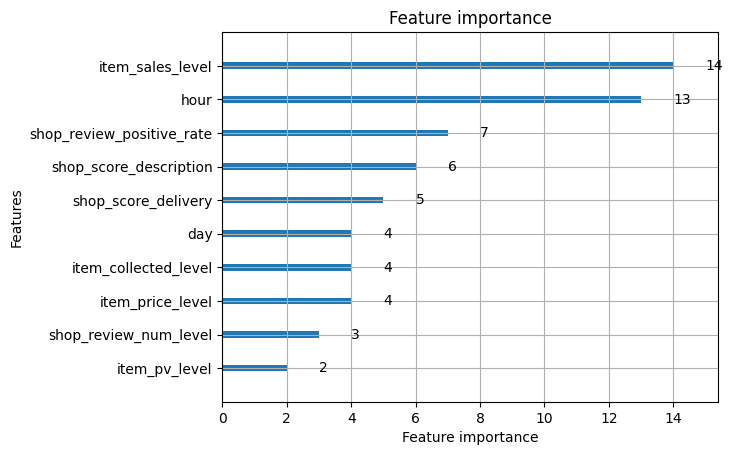

In [18]:
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation
import matplotlib.pyplot as plt
cat_feats = [
    'item_id','item_category_1','item_brand_id','item_city_id',
    'user_id','user_gender_id','user_age_level','user_occupation_id','user_star_level',
    'context_page_id','shop_id','shop_star_level'
]

# 对三个数据集，类别特征-1替换为0
for col in cat_feats:
    X_train[col] = X_train[col].replace(-1, 0)
    X_val[col] = X_val[col].replace(-1, 0)
    X_test[col] = X_test[col].replace(-1, 0)

# 重新构建Dataset！！！
lgb_train = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_feats)
lgb_val = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_feats, reference=lgb_train)

params = {
    'objective':'binary',
    'metric':'binary_logloss',
    'boosting_type':'gbdt',
    'learning_rate':0.05,
    'num_leaves':63,
    'max_depth':-1,
    'scale_pos_weight':50,
    'verbose':1,
    'seed':2026
}

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=2000,
    valid_sets=[lgb_val],
    callbacks=[early_stopping(50), log_evaluation(10)]
)

# 预测、画图
plt.figure(figsize=(10,8))
lgb.plot_importance(model, max_num_features=20)
plt.show()

val_pred = model.predict(X_val, num_iteration=model.best_iteration)
y_pred_prob = model.predict(X_test, num_iteration=model.best_iteration)

In [21]:
params = {
    'objective':'binary',
    'metric':'binary_logloss',
    'boosting_type':'gbdt',
    'learning_rate':0.05,
    'num_leaves':63,
    'scale_pos_weight':20,
    'verbose':1,
    'seed':2026
}

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=500,
    valid_sets=[lgb_val],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30),
        lgb.log_evaluation(10)
    ]
)

[LightGBM] [Info] Number of positive: 8050, number of negative: 412667
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007136 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1221
[LightGBM] [Info] Number of data points in the train set: 420717, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.019134 -> initscore=-3.936969
[LightGBM] [Info] Start training from score -3.936969
Training until validation scores don't improve for 30 rounds
[10]	valid_0's binary_logloss: 0.158945
[20]	valid_0's binary_logloss: 0.212914
[30]	valid_0's binary_logloss: 0.244647
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.0908533


In [22]:
params = {
    'objective':'binary',
    'metric':'binary_logloss',
    'boosting_type':'gbdt',
    'learning_rate':0.03,     # 降学习率
    'num_leaves':31,          # 减小叶子，降低模型容量
    'max_depth':8,
    'scale_pos_weight':10,    # 关键，由20改为10
    'min_child_samples':100,
    'reg_alpha':0.1,          # L1正则
    'reg_lambda':0.1,         # L2正则
    'verbose':1,
    'seed':2026
}

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=800,
    valid_sets=[lgb_val],
    callbacks=[
        lgb.early_stopping(stopping_rounds=40),
        lgb.log_evaluation(10)
    ]
)

[LightGBM] [Info] Number of positive: 8050, number of negative: 412667
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006118 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1221
[LightGBM] [Info] Number of data points in the train set: 420717, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.019134 -> initscore=-3.936969
[LightGBM] [Info] Start training from score -3.936969
Training until validation scores don't improve for 40 rounds
[10]	valid_0's binary_logloss: 0.102932
[20]	valid_0's binary_logloss: 0.123191
[30]	valid_0's binary_logloss: 0.139536
[40]	valid_0's binary_logloss: 0.152098
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.0858697


In [23]:
params = {
    'objective':'binary',
    'metric':'binary_logloss',
    'boosting_type':'gbdt',
    'learning_rate':0.03,
    'num_leaves':31,
    'max_depth':8,
    'scale_pos_weight':4,
    'min_child_samples':100,
    'reg_alpha':0.1,
    'reg_lambda':0.1,
    'verbose':1,
    'seed':2026
}

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=800,
    valid_sets=[lgb_val],
    callbacks=[
        lgb.early_stopping(stopping_rounds=40),
        lgb.log_evaluation(10)
    ]
)

[LightGBM] [Info] Number of positive: 8050, number of negative: 412667
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006592 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1221
[LightGBM] [Info] Number of data points in the train set: 420717, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.019134 -> initscore=-3.936969
[LightGBM] [Info] Start training from score -3.936969
Training until validation scores don't improve for 40 rounds
[10]	valid_0's binary_logloss: 0.0884236
[20]	valid_0's binary_logloss: 0.0934546
[30]	valid_0's binary_logloss: 0.0979232
[40]	valid_0's binary_logloss: 0.101407
Early stopping, best iteration is:
[2]	valid_0's binary_logloss: 0.0855458


In [25]:
params = {
    'objective':'binary',
    'metric':'binary_logloss',
    'boosting_type':'gbdt',
    'learning_rate':0.03,
    'num_leaves':31,
    'max_depth':8,
    'scale_pos_weight':2,
    'min_child_samples':100,
    'reg_alpha':0.1,
    'reg_lambda':0.1,
    'verbose':1,
    'seed':2026
}

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=800,
    valid_sets=[lgb_val],
    callbacks=[
        lgb.early_stopping(stopping_rounds=40),
        lgb.log_evaluation(10)
    ]
)

[LightGBM] [Info] Number of positive: 8050, number of negative: 412667
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011438 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1221
[LightGBM] [Info] Number of data points in the train set: 420717, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.019134 -> initscore=-3.936969
[LightGBM] [Info] Start training from score -3.936969
Training until validation scores don't improve for 40 rounds
[10]	valid_0's binary_logloss: 0.08519
[20]	valid_0's binary_logloss: 0.0857804
[30]	valid_0's binary_logloss: 0.0864766
[40]	valid_0's binary_logloss: 0.0871153
Early stopping, best iteration is:
[7]	valid_0's binary_logloss: 0.0851235


In [26]:
# 使用best_iteration=7预测测试集
y_pred = model.predict(X_test, num_iteration=model.best_iteration)
sub = pd.DataFrame({"prediction": y_pred})
sub.to_csv("submit.csv", index=False)